# SSIM-based local anomaly scoring with a frozen autoencoder

This notebook asks one focused question:

> Can a spatial `1 - SSIM` error map improve Bottle anomaly scoring over whole-image MSE when the trained autoencoder is held fixed?

We load the selected AE-06 checkpoint from notebook 03 and do not retrain or alter its weights. This isolates the scoring rule from the model architecture and training procedure.

## 1. Scoring setup

This is an applied scoring comparison for the Bottle dataset. We keep AE-06 fixed so the notebook can focus on whether SSIM is more useful than whole-image MSE.

Starting settings:

- model: the saved AE-06 checkpoint;
- preprocessing and normal train/validation split: identical to notebook 03;
- SSIM window: 11 x 11 Gaussian, sigma 1.5;
- local anomaly map: `1 - SSIM`, averaged over RGB channels;
- image aggregation: mean of the highest-error 1% of pixels;
- threshold: 95th percentile of normal-validation scores.

The 1% aggregation matches the local aggregation scale used for masked-restoration scoring in notebook 03. We compare it directly with AE-06 whole-image MSE. These settings are clear starting choices rather than claims that they are universally optimal.

In [9]:
from pathlib import Path
import random

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from PIL import Image
from sklearn.metrics import (
    average_precision_score,
    balanced_accuracy_score,
    classification_report,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from torch import nn
from torch.utils.data import DataLoader
from torchvision import transforms

from anomaly_detection import MVTecImageDataset, build_mvtec_manifest

SEED = 17
IMAGE_SIZE = 256
BATCH_SIZE = 16
THRESHOLD_PERCENTILE = 95
SSIM_WINDOW_SIZE = 11
SSIM_SIGMA = 1.5
SSIM_TOP_FRACTION = 0.01
SSIM_IMPLEMENTATION = 'direct_2d'  # Try 'separable' if memory or speed is a problem
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
NUM_WORKERS = 0  # Portable default for notebooks
PIN_MEMORY = DEVICE.type == 'cuda'

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

print(f'Using {DEVICE}')

Using cuda


## 2. Reproduce the Bottle split and load AE-06

Only normal training images participate in the original 80/20 split. Notebook 04 uses the resulting normal validation images to calculate thresholds and the Bottle test set to compare detection performance.

In [10]:
project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent

data_path = project_root / 'data/mvtec'
checkpoint_path = project_root / 'models/ae06_conv_autoencoder16.pt'

manifest = build_mvtec_manifest(data_path)
bottle_train = manifest.query(
    "product == 'bottle' and split == 'train' and not is_anomaly"
).reset_index(drop=True)
bottle_test = manifest.query(
    "product == 'bottle' and split == 'test'"
).reset_index(drop=True)

train_df, validation_df = train_test_split(
    bottle_train, test_size=0.2, random_state=SEED
)
validation_df = validation_df.reset_index(drop=True)

image_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
])
train_dataset = MVTecImageDataset(train_df.reset_index(drop=True), transform=image_transform)
validation_dataset = MVTecImageDataset(validation_df, transform=image_transform)
test_dataset = MVTecImageDataset(bottle_test, transform=image_transform)
validation_loader = DataLoader(
    validation_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)
test_loader = DataLoader(
    test_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
)

print(f'Normal training images: {len(train_dataset)}')
print(f'Normal validation images: {len(validation_dataset)}')
print(f'Bottle test images: {len(test_dataset)}')
print(f'Checkpoint: {checkpoint_path}')

Normal training images: 167
Normal validation images: 42
Bottle test images: 83
Checkpoint: /home/ali/projects/anomaly-detection/models/ae06_conv_autoencoder16.pt


In [11]:
class ConvAutoencoder16(nn.Module):
    """AE-06 architecture: four stages and a 128 x 16 x 16 latent tensor."""

    def __init__(self):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, stride=2, padding=1), nn.ReLU(),
            nn.Conv2d(128, 128, 4, stride=2, padding=1), nn.ReLU(),
        )
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 128, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1), nn.Sigmoid(),
        )

    def forward(self, images):
        return self.decoder(self.encoder(images))


if not checkpoint_path.exists():
    raise FileNotFoundError(
        f'Missing {checkpoint_path}. Run notebook 03 to create the AE-06 checkpoint.'
    )

model = ConvAutoencoder16().to(DEVICE)
checkpoint = torch.load(checkpoint_path, map_location=DEVICE, weights_only=False)
metadata = checkpoint.get('metadata', {})
if metadata.get('experiment') != 'AE-06':
    raise ValueError(
        f"Expected an AE-06 checkpoint, found {metadata.get('experiment')!r}."
    )
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()
model.requires_grad_(False)

print(f"Loaded AE-06 selected at epoch {metadata.get('best_epoch')}")
print(f"Recorded validation MSE: {metadata.get('best_validation_loss'):.6f}")

Loaded AE-06 selected at epoch 199
Recorded validation MSE: 0.000553


## 3. Local SSIM error

SSIM compares local luminance, contrast, and structure. For each pixel we calculate SSIM separately over the RGB channels and average the channel results:

\[
A_{SSIM}(p) = 1 - \frac{1}{3}\sum_{c=1}^{3} SSIM_c(p).
\]

An identical image should have an anomaly map close to zero. We use reflection padding to avoid introducing artificial dark borders before the Gaussian-window calculations. The default `direct_2d` implementation applies the full 11 x 11 Gaussian kernel. A mathematically equivalent `separable` option is retained for machines where the direct calculation is slow or memory-intensive.

In [12]:
def gaussian_kernel_1d(window_size, sigma, device, dtype):
    coordinates = torch.arange(window_size, device=device, dtype=dtype)
    coordinates = coordinates - (window_size - 1) / 2
    kernel_1d = torch.exp(-(coordinates.square()) / (2 * sigma**2))
    kernel_1d = kernel_1d / kernel_1d.sum()
    return kernel_1d


def ssim_error_map(original, reconstruction, window_size=11, sigma=1.5):
    """Return a B x H x W local 1-SSIM map for images in [0, 1]."""
    if original.shape != reconstruction.shape:
        raise ValueError('Original and reconstruction must have matching shapes.')
    if window_size % 2 == 0:
        raise ValueError('SSIM window size must be odd.')

    channels = original.shape[1]
    kernel_1d = gaussian_kernel_1d(
        window_size, sigma, original.device, original.dtype
    )
    kernel_2d = torch.outer(kernel_1d, kernel_1d).view(
        1, 1, window_size, window_size
    ).expand(channels, 1, window_size, window_size).contiguous()
    horizontal_kernel = kernel_1d.view(1, 1, 1, window_size).expand(
        channels, 1, 1, window_size
    ).contiguous()
    vertical_kernel = kernel_1d.view(1, 1, window_size, 1).expand(
        channels, 1, window_size, 1
    ).contiguous()
    padding = window_size // 2

    def local_average(values):
        padded = F.pad(
            values, (padding, padding, padding, padding), mode='reflect'
        )
        if SSIM_IMPLEMENTATION == 'direct_2d':
            return F.conv2d(padded, kernel_2d, groups=channels)
        if SSIM_IMPLEMENTATION == 'separable':
            horizontal_average = F.conv2d(
                padded, horizontal_kernel, groups=channels
            )
            return F.conv2d(
                horizontal_average, vertical_kernel, groups=channels
            )
        raise ValueError(
            "SSIM_IMPLEMENTATION must be 'direct_2d' or 'separable'."
        )

    mu_x = local_average(original)
    mu_y = local_average(reconstruction)
    sigma_x = (local_average(original.square()) - mu_x.square()).clamp_min(0)
    sigma_y = (local_average(reconstruction.square()) - mu_y.square()).clamp_min(0)
    sigma_xy = local_average(original * reconstruction) - mu_x * mu_y

    c1 = 0.01**2
    c2 = 0.03**2
    numerator = (2 * mu_x * mu_y + c1) * (2 * sigma_xy + c2)
    denominator = (
        (mu_x.square() + mu_y.square() + c1)
        * (sigma_x + sigma_y + c2)
    )
    ssim_by_channel = numerator / denominator.clamp_min(torch.finfo(original.dtype).eps)
    return (1 - ssim_by_channel.mean(dim=1)).clamp(0, 2)


check = torch.rand(2, 3, 64, 64, device=DEVICE)
identity_error = ssim_error_map(
    check, check, SSIM_WINDOW_SIZE, SSIM_SIGMA
)
assert identity_error.max().item() < 1e-5
print(f'SSIM implementation: {SSIM_IMPLEMENTATION}')
print(f'Identical-image maximum 1-SSIM error: {identity_error.max().item():.2e}')

SSIM implementation: direct_2d
Identical-image maximum 1-SSIM error: 0.00e+00


AE-06 whole-image MSE: mean=0.000553, threshold=0.000747, flagged=3 of 42 (7.1%)
AE-06 top-1% local 1-SSIM: mean=0.830373, threshold=0.908901, flagged=3 of 42 (7.1%)


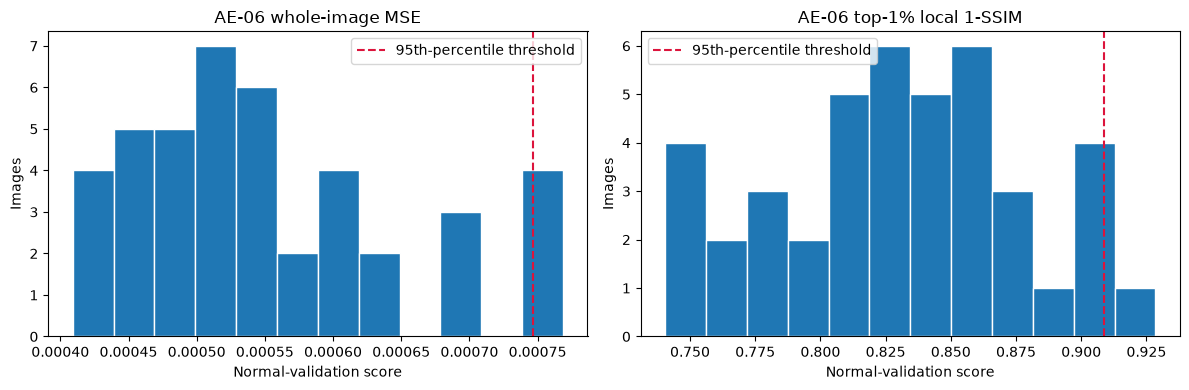

In [13]:
def score_loader(model_to_score, loader):
    """Calculate whole-image MSE and top-1% local SSIM scores."""
    rows = []
    model_to_score.eval()
    with torch.inference_mode():
        for images, labels, paths in loader:
            images = images.to(DEVICE, non_blocking=PIN_MEMORY)
            reconstructions = model_to_score(images)

            mse_scores = (reconstructions - images).square().mean(dim=(1, 2, 3))
            local_maps = ssim_error_map(
                images, reconstructions, SSIM_WINDOW_SIZE, SSIM_SIGMA
            )
            top_pixel_count = max(
                1, int(np.ceil(local_maps[0].numel() * SSIM_TOP_FRACTION))
            )
            ssim_scores = torch.topk(
                local_maps.flatten(start_dim=1), top_pixel_count, dim=1
            ).values.mean(dim=1)

            rows.extend({
                'path': str(path),
                'label': int(label),
                'mse_score': float(mse_score),
                'ssim_score': float(ssim_score),
            } for path, label, mse_score, ssim_score in zip(
                paths, labels, mse_scores.cpu(), ssim_scores.cpu()
            ))
    return pd.DataFrame(rows)


validation_results = score_loader(model, validation_loader)
assert validation_results['label'].eq(0).all()

score_columns = {
    'AE-06 whole-image MSE': 'mse_score',
    'AE-06 top-1% local 1-SSIM': 'ssim_score',
}
validation_thresholds = {
    name: np.percentile(validation_results[column], THRESHOLD_PERCENTILE)
    for name, column in score_columns.items()
}

for name, column in score_columns.items():
    threshold = validation_thresholds[name]
    flagged = validation_results[column] > threshold
    print(
        f'{name}: mean={validation_results[column].mean():.6f}, '
        f'threshold={threshold:.6f}, '
        f'flagged={flagged.sum()} of {len(flagged)} ({flagged.mean():.1%})'
    )

figure, axes = plt.subplots(1, 2, figsize=(12, 4))
for axis, (name, column) in zip(axes, score_columns.items()):
    axis.hist(validation_results[column], bins=12, edgecolor='white')
    axis.axvline(
        validation_thresholds[name], color='crimson', linestyle='--',
        label='95th-percentile threshold'
    )
    axis.set_title(name)
    axis.set_xlabel('Normal-validation score')
    axis.set_ylabel('Images')
    axis.legend()
plt.tight_layout()
plt.show()

## 4. Bottle evaluation

The following cell applies both validation-derived thresholds and compares the methods on the same AE-06 reconstructions. This makes the effect of changing the anomaly score easy to interpret.


AE-06 whole-image MSE
              precision    recall  f1-score   support

        good       0.53      0.80      0.64        20
     anomaly       0.92      0.78      0.84        63

    accuracy                           0.78        83
   macro avg       0.73      0.79      0.74        83
weighted avg       0.83      0.78      0.80        83


AE-06 top-1% local 1-SSIM
              precision    recall  f1-score   support

        good       0.34      0.85      0.49        20
     anomaly       0.91      0.48      0.62        63

    accuracy                           0.57        83
   macro avg       0.62      0.66      0.56        83
weighted avg       0.77      0.57      0.59        83



,threshold,AUROC,PR-AUC,balanced_accuracy,good_correct,false_alarms,defects_detected,defects_missed
method,,,,,,,,
AE-06 whole-image MSE,0.000747,0.876984,0.958567,0.788889,16,4,49,14
AE-06 top-1% local 1-SSIM,0.908901,0.786508,0.925820,0.663095,17,3,30,33


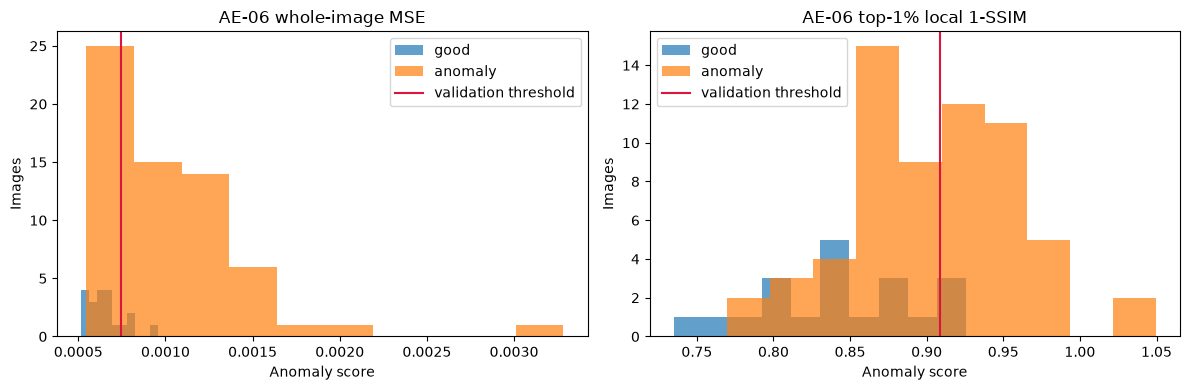

In [14]:
RUN_TEST_EVALUATION = True

if RUN_TEST_EVALUATION:
    test_results = score_loader(model, test_loader)
    metric_rows = []

    for method_name, score_column in score_columns.items():
        threshold = validation_thresholds[method_name]
        predictions = (test_results[score_column] > threshold).astype(int)
        labels = test_results['label'].to_numpy()

        metric_rows.append({
            'method': method_name,
            'threshold': threshold,
            'AUROC': roc_auc_score(labels, test_results[score_column]),
            'PR-AUC': average_precision_score(labels, test_results[score_column]),
            'balanced_accuracy': balanced_accuracy_score(labels, predictions),
            'good_correct': int(((labels == 0) & (predictions == 0)).sum()),
            'false_alarms': int(((labels == 0) & (predictions == 1)).sum()),
            'defects_detected': int(((labels == 1) & (predictions == 1)).sum()),
            'defects_missed': int(((labels == 1) & (predictions == 0)).sum()),
        })
        test_results[f'{score_column}_prediction'] = predictions

        print(f'\n{method_name}')
        print(classification_report(
            labels, predictions, target_names=['good', 'anomaly'],
            zero_division=0,
        ))

    comparison = pd.DataFrame(metric_rows).set_index('method')
    display(comparison.round(6))

    figure, axes = plt.subplots(1, 2, figsize=(12, 4))
    for axis, (method_name, score_column) in zip(axes, score_columns.items()):
        axis.hist(
            test_results.loc[test_results.label == 0, score_column],
            alpha=.7, label='good'
        )
        axis.hist(
            test_results.loc[test_results.label == 1, score_column],
            alpha=.7, label='anomaly'
        )
        axis.axvline(
            validation_thresholds[method_name], color='crimson',
            label='validation threshold'
        )
        axis.set_title(method_name)
        axis.set_xlabel('Anomaly score')
        axis.set_ylabel('Images')
        axis.legend()
    plt.tight_layout()
    plt.show()
else:
    print('Test evaluation is disabled.')

## 5. What local SSIM highlights

This 4 x 4 grid uses the SSIM decision. It samples two missed and two detected defects with seed 17 and shows the input, reconstruction, local `1 - SSIM` map, and known defect boundary. The ground-truth mask is for interpretation only; it is never used by the score.

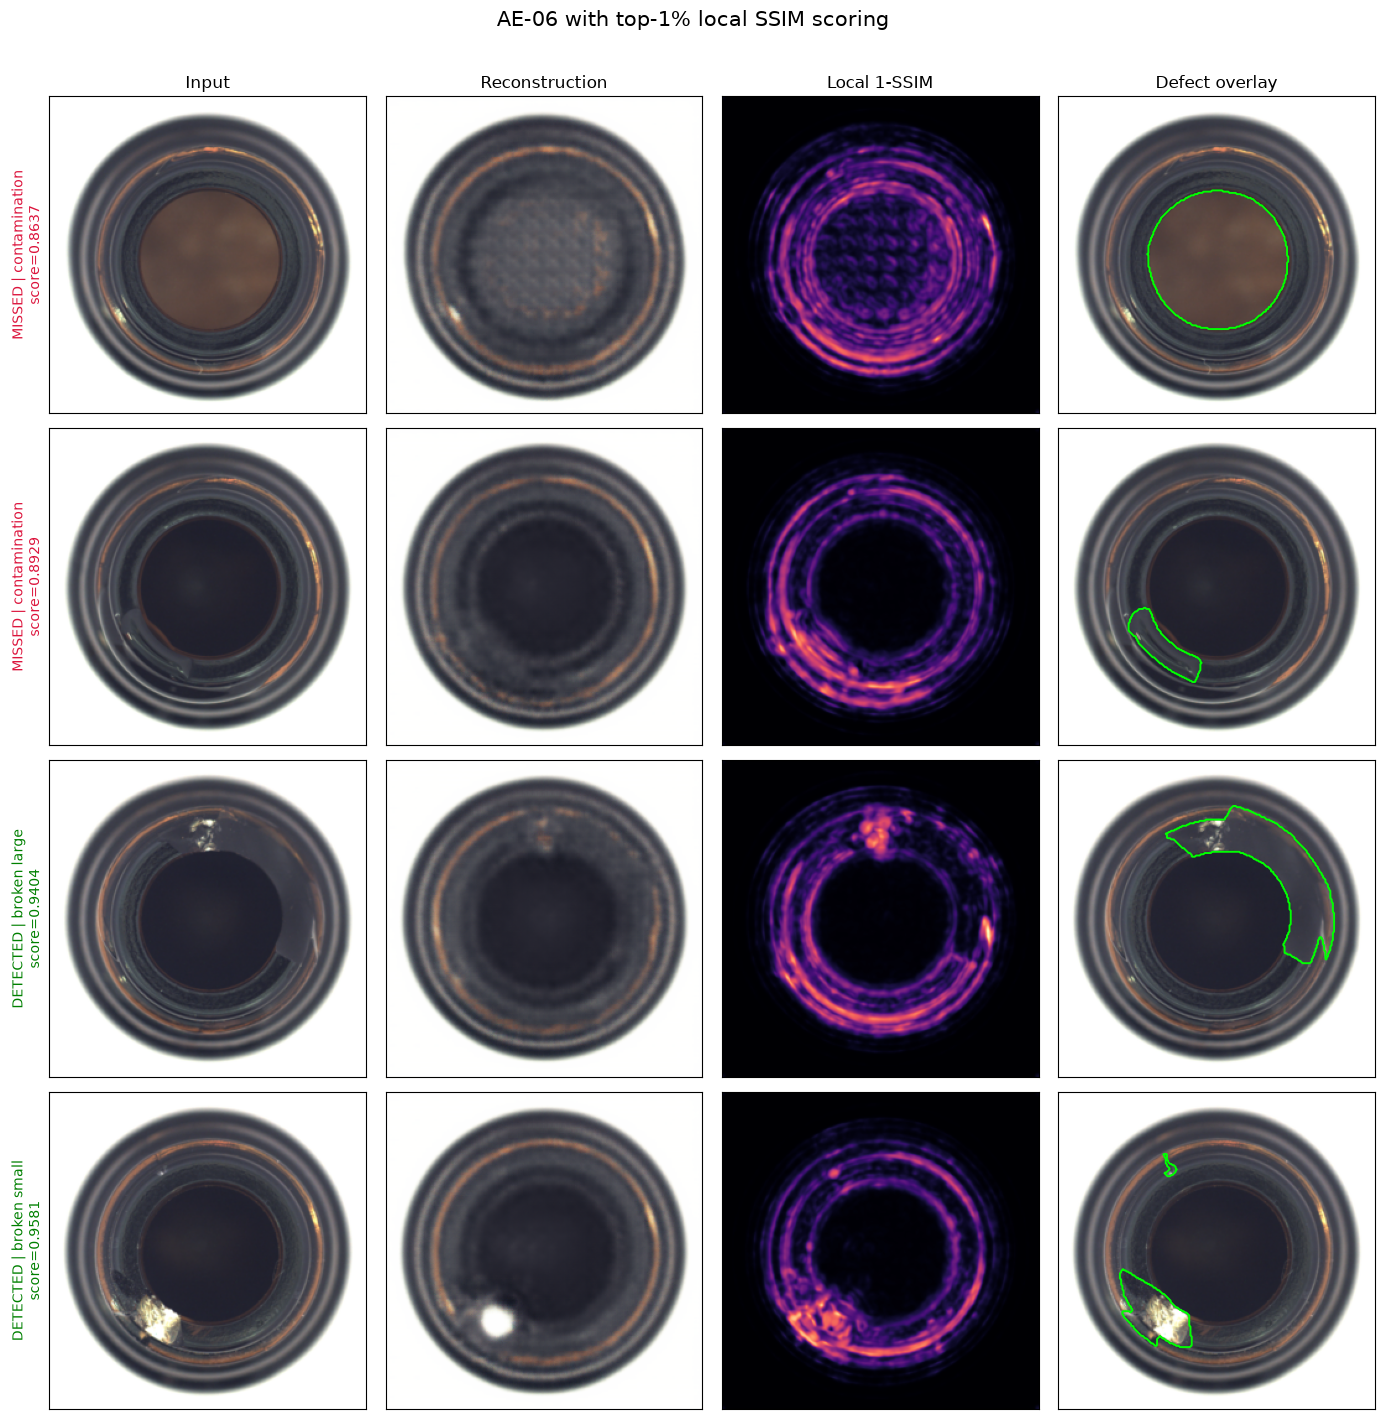

In [15]:
def ground_truth_mask_path(image_path):
    image_path = Path(image_path)
    return (
        image_path.parents[2] / 'ground_truth' / image_path.parent.name
        / f'{image_path.stem}_mask.png'
    )


def show_ssim_examples(results, count_per_decision=2):
    prediction_column = 'ssim_score_prediction'
    missed = results.index[
        (results.label == 1) & (results[prediction_column] == 0)
    ].to_numpy()
    detected = results.index[
        (results.label == 1) & (results[prediction_column] == 1)
    ].to_numpy()
    if len(missed) < count_per_decision or len(detected) < count_per_decision:
        raise ValueError('Not enough missed and detected defects for a balanced grid.')

    rng = np.random.default_rng(SEED)
    selected = np.concatenate([
        rng.choice(missed, count_per_decision, replace=False),
        rng.choice(detected, count_per_decision, replace=False),
    ])
    decisions = ['MISSED'] * count_per_decision + ['DETECTED'] * count_per_decision

    path_to_index = {
        str(path): index for index, path in enumerate(test_dataset.frame['path'])
    }
    images = torch.stack([
        test_dataset[path_to_index[results.loc[index, 'path']]][0]
        for index in selected
    ]).to(DEVICE)

    with torch.inference_mode():
        reconstructions = model(images)
        local_maps = ssim_error_map(
            images, reconstructions, SSIM_WINDOW_SIZE, SSIM_SIGMA
        )

    images_np = images.cpu().permute(0, 2, 3, 1).numpy()
    reconstructions_np = reconstructions.cpu().permute(0, 2, 3, 1).numpy()
    maps_np = local_maps.cpu().numpy()
    map_max = max(float(maps_np.max()), 1e-12)

    figure, axes = plt.subplots(4, 4, figsize=(14, 14))
    for axis, title in zip(
        axes[0], ['Input', 'Reconstruction', 'Local 1-SSIM', 'Defect overlay']
    ):
        axis.set_title(title)

    for row, (result_index, decision) in enumerate(zip(selected, decisions)):
        result = results.loc[result_index]
        axes[row, 0].imshow(images_np[row].clip(0, 1))
        axes[row, 1].imshow(reconstructions_np[row].clip(0, 1))
        axes[row, 2].imshow(maps_np[row], cmap='magma', vmin=0, vmax=map_max)
        axes[row, 3].imshow(images_np[row].clip(0, 1))

        with Image.open(ground_truth_mask_path(result.path)) as mask_image:
            mask = np.asarray(mask_image.convert('L').resize(
                (IMAGE_SIZE, IMAGE_SIZE), Image.Resampling.NEAREST
            )) > 0
        axes[row, 3].contour(mask, levels=[0.5], colors='lime', linewidths=1.4)

        defect_type = Path(result.path).parent.name.replace('_', ' ')
        axes[row, 0].set_ylabel(
            f'{decision} | {defect_type}\n'
            f"score={result.ssim_score:.4f}",
            color='crimson' if decision == 'MISSED' else 'green',
        )
        for axis in axes[row]:
            axis.set_xticks([])
            axis.set_yticks([])

    figure.suptitle('AE-06 with top-1% local SSIM scoring', fontsize=15, y=1.01)
    plt.tight_layout()
    plt.show()


if RUN_TEST_EVALUATION:
    show_ssim_examples(test_results)

## 6. AE-10: AE-06 architecture trained with pure SSIM loss

AE-10 is a deliberately narrow continuation of notebook 03. It reuses AE-06's `128 x 16 x 16` architecture, normal-only training split, batch size, Adam schedule, 200-epoch budget, and checkpoint-selection protocol; refer to notebook 03 for the architectural motivation and earlier MSE experiments. The only intended experimental change here is replacing MSE completely with mean `1 - SSIM`. There is no MSE term in AE-10's training or validation objective. The SSIM window remains 11 x 11 with sigma 1.5.

Training uses separable Gaussian filtering, which is mathematically equivalent to the direct 2-D Gaussian kernel and substantially reduces memory use. The anomaly score remains the predeclared top-1% local `1 - SSIM` score from Section 3, with a 95th-percentile normal-validation threshold.

> **Evaluation status:** this experiment was proposed after earlier Bottle test results were already visible. Its immediate test result is therefore reused-test follow-up evidence, not performance on a fresh held-out test set. We record the result without using it to revise this run.

Epoch 001: train=0.504055, validation=0.504800, lr=1e-03
Epoch 010: train=0.163783, validation=0.160950, lr=1e-03
Epoch 020: train=0.109124, validation=0.108199, lr=1e-03
Epoch 030: train=0.091892, validation=0.092036, lr=1e-03
Epoch 040: train=0.081089, validation=0.082550, lr=1e-03
Epoch 050: train=0.076717, validation=0.077334, lr=1e-03
Epoch 060: train=0.071151, validation=0.073479, lr=1e-03
Epoch 070: train=0.068426, validation=0.070456, lr=1e-03
Epoch 080: train=0.065444, validation=0.067557, lr=1e-03
Epoch 090: train=0.063029, validation=0.065724, lr=1e-03
Epoch 100: train=0.060818, validation=0.063449, lr=1e-03
Epoch 110: train=0.058834, validation=0.061574, lr=1e-03
Epoch 120: train=0.057112, validation=0.060564, lr=1e-03
Epoch 130: train=0.054941, validation=0.058361, lr=1e-03
Epoch 140: train=0.054316, validation=0.057090, lr=1e-03
Epoch 150: train=0.051794, validation=0.055921, lr=1e-03
Epoch 160: train=0.050629, validation=0.054664, lr=1e-04
Epoch 170: train=0.050442, vali

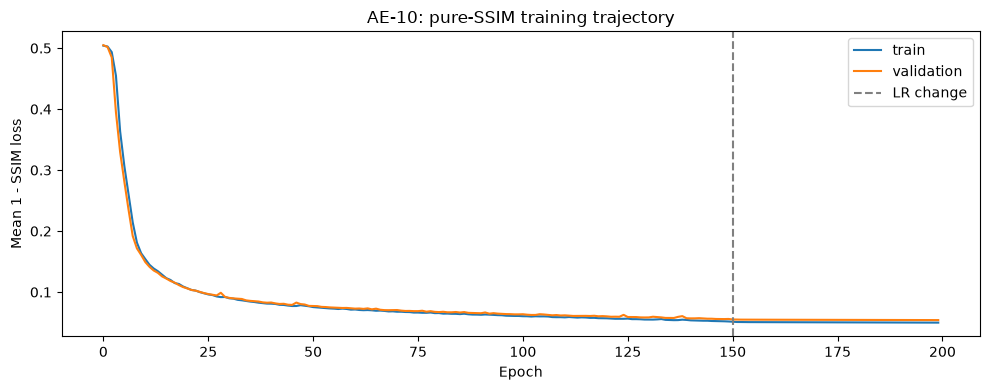

In [16]:
AE10_MAX_EPOCHS = 200
AE10_INITIAL_LEARNING_RATE = 1e-3
AE10_LR_CHANGE_EPOCH = 150
AE10_REFINEMENT_LEARNING_RATE = 1e-4
AE10_SEED = SEED + 10
AE10_CHECKPOINT_PATH = project_root / 'models/ae10_conv_autoencoder16_pure_ssim.pt'
RETRAIN_AE10 = False

random.seed(AE10_SEED)
np.random.seed(AE10_SEED)
torch.manual_seed(AE10_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(AE10_SEED)

model_ae10 = ConvAutoencoder16().to(DEVICE)
optimizer_ae10 = torch.optim.Adam(
    model_ae10.parameters(), lr=AE10_INITIAL_LEARNING_RATE
)
loader_generator_ae10 = torch.Generator().manual_seed(AE10_SEED)
train_loader_ae10 = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    generator=loader_generator_ae10, num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)
history_ae10 = {'train_loss': [], 'validation_loss': [], 'learning_rate': []}
best_validation_loss_ae10 = float('inf')
best_epoch_ae10 = 0
best_state_ae10 = None

train_ae10 = RETRAIN_AE10 or not AE10_CHECKPOINT_PATH.exists()
if not train_ae10:
    checkpoint_ae10 = torch.load(
        AE10_CHECKPOINT_PATH, map_location=DEVICE, weights_only=False
    )
    if checkpoint_ae10.get('metadata', {}).get('experiment') != 'AE-10':
        raise ValueError('The AE-10 checkpoint has unexpected metadata.')
    model_ae10.load_state_dict(checkpoint_ae10['model_state_dict'])
    metadata_ae10 = checkpoint_ae10['metadata']
    history_ae10 = metadata_ae10['history']
    best_validation_loss_ae10 = metadata_ae10['best_validation_loss']
    best_epoch_ae10 = metadata_ae10['best_epoch']
    print(f'Loaded existing AE-10 checkpoint: {AE10_CHECKPOINT_PATH}')
else:
    previous_ssim_implementation = SSIM_IMPLEMENTATION
    SSIM_IMPLEMENTATION = 'separable'
    for epoch in range(1, AE10_MAX_EPOCHS + 1):
        if epoch == AE10_LR_CHANGE_EPOCH + 1:
            for parameter_group in optimizer_ae10.param_groups:
                parameter_group['lr'] = AE10_REFINEMENT_LEARNING_RATE

        model_ae10.train()
        train_loss_total = 0.0
        for images, _, _ in train_loader_ae10:
            images = images.to(DEVICE, non_blocking=PIN_MEMORY)
            optimizer_ae10.zero_grad()
            reconstructions = model_ae10(images)
            loss = ssim_error_map(
                images, reconstructions, SSIM_WINDOW_SIZE, SSIM_SIGMA
            ).mean()
            loss.backward()
            optimizer_ae10.step()
            train_loss_total += loss.item() * len(images)

        model_ae10.eval()
        validation_loss_total = 0.0
        with torch.inference_mode():
            for images, _, _ in validation_loader:
                images = images.to(DEVICE, non_blocking=PIN_MEMORY)
                reconstructions = model_ae10(images)
                validation_loss = ssim_error_map(
                    images, reconstructions, SSIM_WINDOW_SIZE, SSIM_SIGMA
                ).mean()
                validation_loss_total += validation_loss.item() * len(images)

        train_loss = train_loss_total / len(train_dataset)
        validation_loss = validation_loss_total / len(validation_dataset)
        current_lr = optimizer_ae10.param_groups[0]['lr']
        history_ae10['train_loss'].append(train_loss)
        history_ae10['validation_loss'].append(validation_loss)
        history_ae10['learning_rate'].append(current_lr)
        if validation_loss < best_validation_loss_ae10:
            best_validation_loss_ae10 = validation_loss
            best_epoch_ae10 = epoch
            best_state_ae10 = {
                key: value.detach().cpu().clone()
                for key, value in model_ae10.state_dict().items()
            }
        if epoch == 1 or epoch % 10 == 0:
            print(
                f'Epoch {epoch:03d}: train={train_loss:.6f}, '
                f'validation={validation_loss:.6f}, lr={current_lr:.0e}'
            )

    SSIM_IMPLEMENTATION = previous_ssim_implementation
    model_ae10.load_state_dict(best_state_ae10)
    torch.save({
        'model_state_dict': model_ae10.state_dict(),
        'metadata': {
            'experiment': 'AE-10',
            'loss': 'pure mean 1-SSIM',
            'best_epoch': best_epoch_ae10,
            'best_validation_loss': best_validation_loss_ae10,
            'history': history_ae10,
            'seed': AE10_SEED,
        },
    }, AE10_CHECKPOINT_PATH)
    print(f'Saved AE-10 checkpoint: {AE10_CHECKPOINT_PATH}')

model_ae10.eval()
model_ae10.requires_grad_(False)
print(f'AE-10 best epoch: {best_epoch_ae10}')
print(f'AE-10 best normal-validation mean 1-SSIM: {best_validation_loss_ae10:.6f}')

plt.figure(figsize=(10, 4))
plt.plot(history_ae10['train_loss'], label='train')
plt.plot(history_ae10['validation_loss'], label='validation')
plt.axvline(AE10_LR_CHANGE_EPOCH, color='grey', linestyle='--', label='LR change')
plt.xlabel('Epoch')
plt.ylabel('Mean 1 - SSIM loss')
plt.title('AE-10: pure-SSIM training trajectory')
plt.legend()
plt.tight_layout()
plt.show()

,threshold,AUROC,PR-AUC,balanced_accuracy,good_correct,false_alarms,defects_detected,defects_missed
AE-10 pure-SSIM training + top-1% SSIM scoring,0.743924,0.82381,0.926793,0.624603,18.0,2.0,22.0,41.0


              precision    recall  f1-score   support

        good       0.31      0.90      0.46        20
     anomaly       0.92      0.35      0.51        63

    accuracy                           0.48        83
   macro avg       0.61      0.62      0.48        83
weighted avg       0.77      0.48      0.49        83



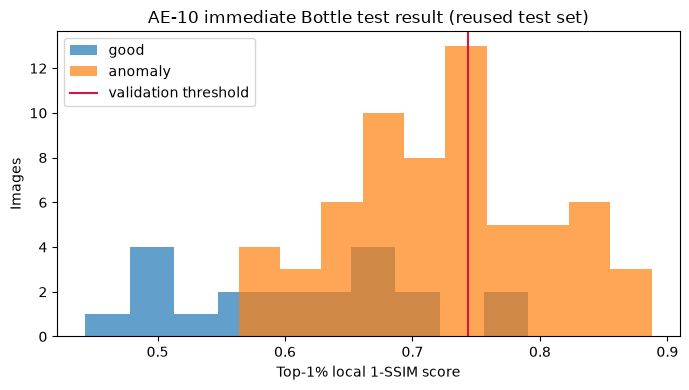

In [17]:
# Freeze the normal-validation threshold, then immediately evaluate once.
ae10_validation_results = score_loader(model_ae10, validation_loader)
ae10_threshold = np.percentile(
    ae10_validation_results['ssim_score'], THRESHOLD_PERCENTILE
)
ae10_test_results = score_loader(model_ae10, test_loader)
ae10_labels = ae10_test_results['label'].to_numpy()
ae10_predictions = (ae10_test_results['ssim_score'] > ae10_threshold).astype(int)
ae10_true_negatives = int(((ae10_labels == 0) & (ae10_predictions == 0)).sum())
ae10_false_positives = int(((ae10_labels == 0) & (ae10_predictions == 1)).sum())
ae10_true_positives = int(((ae10_labels == 1) & (ae10_predictions == 1)).sum())
ae10_false_negatives = int(((ae10_labels == 1) & (ae10_predictions == 0)).sum())

ae10_metrics = pd.Series({
    'threshold': ae10_threshold,
    'AUROC': roc_auc_score(ae10_labels, ae10_test_results['ssim_score']),
    'PR-AUC': average_precision_score(ae10_labels, ae10_test_results['ssim_score']),
    'balanced_accuracy': balanced_accuracy_score(ae10_labels, ae10_predictions),
    'good_correct': ae10_true_negatives,
    'false_alarms': ae10_false_positives,
    'defects_detected': ae10_true_positives,
    'defects_missed': ae10_false_negatives,
}, name='AE-10 pure-SSIM training + top-1% SSIM scoring')
display(ae10_metrics.to_frame().T.round(6))
print(classification_report(
    ae10_labels, ae10_predictions, target_names=['good', 'anomaly'],
    zero_division=0,
))

plt.figure(figsize=(7, 4))
plt.hist(ae10_test_results.loc[ae10_labels == 0, 'ssim_score'], alpha=.7, label='good')
plt.hist(ae10_test_results.loc[ae10_labels == 1, 'ssim_score'], alpha=.7, label='anomaly')
plt.axvline(ae10_threshold, color='crimson', label='validation threshold')
plt.xlabel('Top-1% local 1-SSIM score')
plt.ylabel('Images')
plt.title('AE-10 immediate Bottle test result (reused test set)')
plt.legend()
plt.tight_layout()
plt.show()

## 7. Result and conclusion

### 7.1 Comparison with notebook 03

| Method | Training loss | Anomaly score | AUROC | PR-AUC | Balanced accuracy | Good correct / false alarms | Defects detected / missed |
| --- | --- | --- | ---: | ---: | ---: | ---: | ---: |
| AE-06 (notebook 03 control) | MSE | Whole-image MSE | **0.8770** | **0.9586** | **0.7889** | 16 / 4 | **49 / 14** |
| Experiment 1: frozen AE-06 | MSE | Top-1% local `1 - SSIM` | 0.7865 | 0.9258 | 0.6631 | 17 / 3 | 30 / 33 |
| Experiment 2: AE-10 | Pure mean `1 - SSIM` | Top-1% local `1 - SSIM` | 0.8238 | 0.9268 | 0.6246 | **18 / 2** | 22 / 41 |
| Best notebook 03 feature baseline | Frozen ResNet-18 + 5-NN | Feature distance | **0.9881** | **0.9960** | **0.9433** | **19 / 1** | **59 / 4** |

### 7.2 Experiment 1: SSIM scoring on the MSE-trained AE-06

Changing only the anomaly score from whole-image MSE to top-1% local `1 - SSIM` made AE-06 substantially weaker. AUROC fell from 0.8770 to 0.7865, PR-AUC from 0.9586 to 0.9258, and balanced accuracy from 0.7889 to 0.6631. SSIM reduced false alarms slightly, from four to three, but detected only 30 of 63 defects instead of 49. The normal-validation SSIM scores were already high (mean 0.8304 and threshold 0.9089), suggesting that the top 1% was dominated by ordinary local reconstruction discrepancies such as edges, reflections, or decoder artifacts. These discrepancies were not sufficiently specific to defects.

Against the autoencoders in notebook 03, this SSIM score had higher AUROC than AE-04 and the AE-05 variants, and was close to AE-08 clean scoring, but its thresholded performance was poor: only AE-04 had lower balanced accuracy, and its 30 detected defects merely matched AE-05 masked-restoration scoring. A spatial anomaly map is useful for interpretation, but in this experiment it was not a better image-level detector than AE-06's MSE score.

### 7.3 Experiment 2: AE-10 trained with pure SSIM loss

Pure-SSIM training converged steadily and selected the final epoch, with normal-validation mean `1 - SSIM` decreasing to 0.0541. Relative to applying SSIM scoring to the MSE-trained AE-06, AE-10 improved ranking AUROC from 0.7865 to 0.8238 and lowered the normal-validation top-1% threshold from 0.9089 to 0.7439. This is evidence that matching the training objective to structural reconstruction changed the learned reconstructions in a useful way for score ranking.

That ranking improvement did not produce a useful classifier at the frozen 95th-percentile threshold. AE-10 detected only 22 of 63 defects and missed 41, giving balanced accuracy 0.6246, the lowest of all autoencoder results reported across notebooks 03 and 04. It accepted 18 of 20 good images, so its main trade-off was fewer false alarms at the cost of very low anomaly recall. Its AUROC was competitive with AE-08 masked scoring and AE-09, but its PR-AUC of 0.9268 was below all notebook 03 follow-up models AE-06 to AE-09. The difference between acceptable AUROC and weak thresholded detection shows that ranking quality and threshold calibration must be evaluated separately.

### 7.4 Final decision and limitations

Neither SSIM experiment improves on notebook 03's AE-06 MSE result, and both remain far behind the frozen ResNet-18 + 5-NN baseline. AE-06 therefore remains the strongest autoencoder for ranking and defect detection, while AE-08 masked restoration remains the preferable autoencoder when minimizing false alarms is more important. Pure SSIM loss is retained as informative negative evidence rather than the selected method.

This conclusion is limited to Bottle, one normal split, one AE-10 seed, one SSIM window, and one predeclared aggregation rule. AE-10 also used a different random seed from AE-06, so the comparison does not isolate loss choice perfectly. Its validation loss was still improving at epoch 200, but extending training or changing the threshold after seeing these test results would tune to a reused test set. Both experiments were conducted after notebook 03's Bottle test results were known and must therefore be described as follow-up evidence, not evaluation on a fresh final test set.